# WCC ETC 

### Import main package

In [1]:
from importlib import reload
import wcc_etc
reload(wcc_etc)

/Users/gudmundurstefansson/anaconda3/envs/py313/lib/python3.13/site-packages/wcc_etc


<module 'wcc_etc' from '/Users/gudmundurstefansson/anaconda3/envs/py313/lib/python3.13/site-packages/wcc_etc/__init__.py'>

### Initialize

Initializing WCC ETC. Reading in Config
Setting up WCC ETC with current configuration
Reading total throughput from file
Read noise: 3.0442890448219115 electron(1/2) / pix(1/2)
##################################################
# System Summary from .toml configuration file
# Main
Diameter Primary:            3.06 m
Fnum:                        15.0
Focal Length:               45.98 m
Num mirrors:                  0.0
Surf Area:                   7.38 m2m2

# Detector
Gain Setting:               100.0
Gain:                      0.2612 electron / ct
Sensor Area:                864.0 mm2mm2
Pixel Size:                 3.760 um / pix
Read Noise:                 3.044 electron(1/2) / pix(1/2)
Dark Current:              0.0031 electron / (pix s)
Well depth:               16274.9 electron / pix
# Other
Plate Scale:                0.017 arcsec/pix
Zodi S. brightn.:            22.5 mag/arcsec2
#################################################
Setting wavelength: 5.8e-07 nm


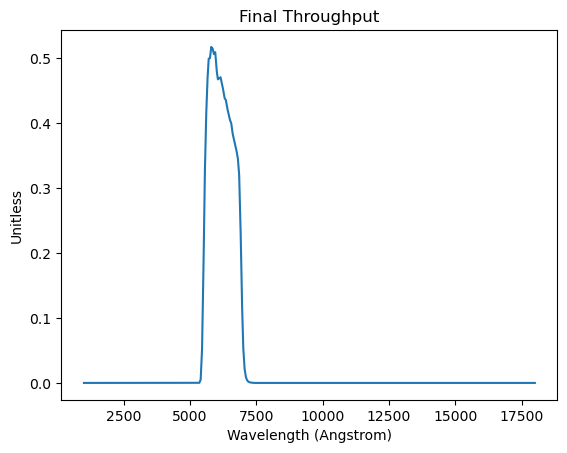

In [12]:
#WCC = wcc_etc.WCCETC("../src/wcc_etc/data/config/config_wcc_kepler_from_final_EOL_zwo.toml")
#WCC = wcc_etc.WCCETC("../src/wcc_etc/data/config/config_wcc_sdssg_from_final_BOL.toml")
WCC = wcc_etc.WCCETC("../src/wcc_etc/data/config/config_wcc_sdssr_from_final_EOL_req.toml")

WCC.setup(verbose=True,plot=True)

# Calculate SNR for a given exposure time and magnitude

########################
Source: Airy PSF (D=3.06 m, λ=0.58 μm), grid=1024², px=0.977 mas
Pixel scales: 0.977 mas/px (x), 0.977 mas/px (y)
Broadening with 10.0mas
Source Count rate total: 2.5655951506053247e/s
Source Count rate total: 9.822339780101151ADU/s
EE = 0.896 at r=70.0mas
Source Count rate at EE: 2.29772041239944e/s
Source Count rate at EE: 8.796785652224408ADU/s
Background Count rate: 4.8580843571029995e-62e/s
Background Count rate: 1.8599097844646855e-61ADU/s
SNR=5.41: in 60.000s


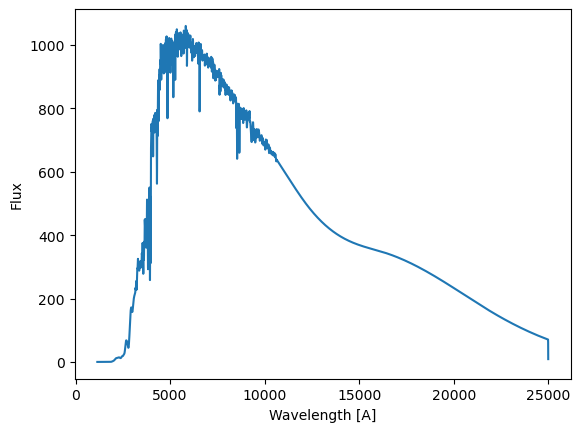

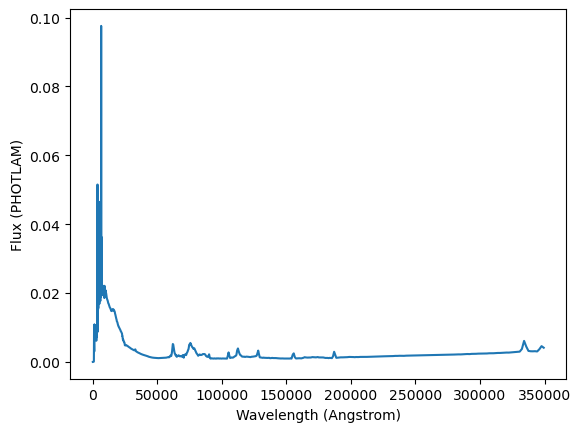

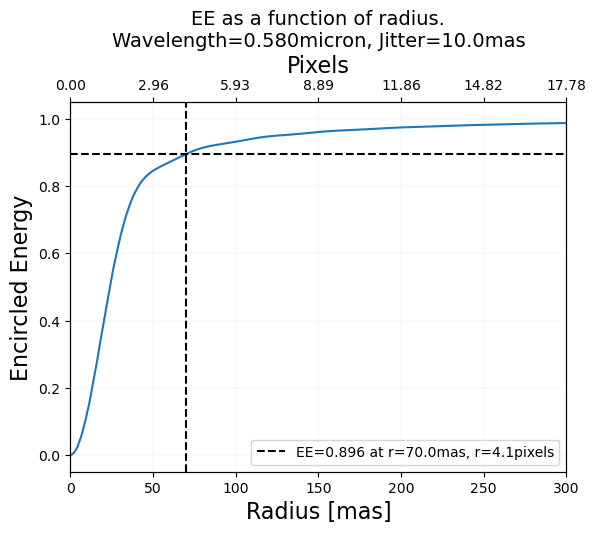

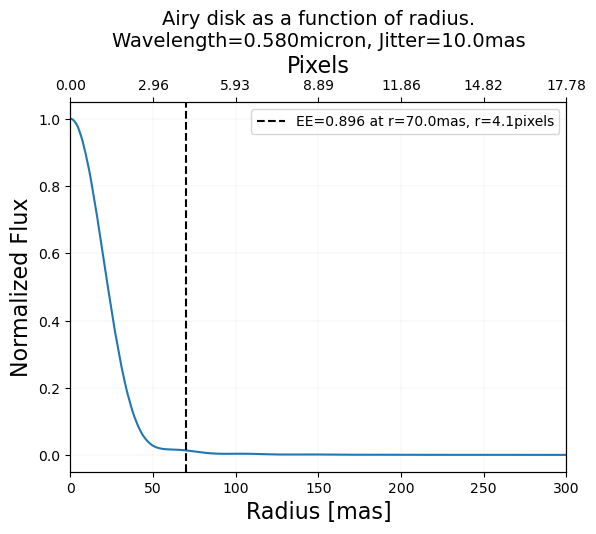

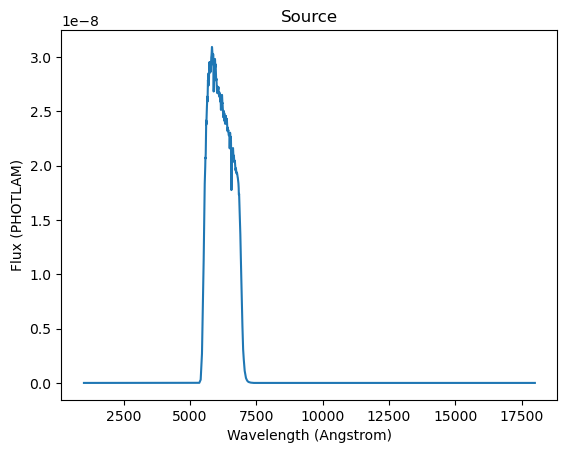

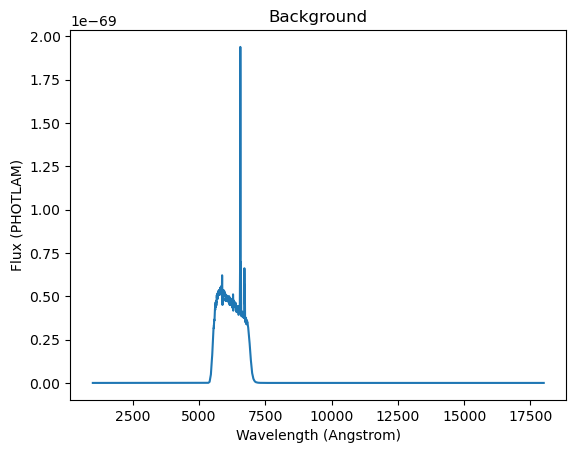

In [16]:
import os

TEXP = 60
MAG = 25.5 # AB mag
BKG_MAG = 180 # vmag / arcsec2 # make background irrelevant
PLOT = True

WCC.set_source(os.path.join(WCC.PICKLES_DIR,WCC.get_default_source_file()),plot=PLOT)
WCC.set_background(background_file=WCC.get_default_background_file(),support_data_path=WCC.GALAXY_BACKGROUND_DIR, plot=PLOT)

print('########################')
snr = WCC.make_observation_and_calc_SNR(flux=MAG, r_aper_mas=70, texp=TEXP,
                                        jitter_sigma_mas=10, bg_flux=BKG_MAG, 
                                        plot=PLOT, verbose=True)
print('SNR={:0.2f}: in {:0.3f}s'.format(snr,TEXP))